In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import torch
from torch import nn
import os, random
from datasets import load_dataset

df = pd.read_csv("/mnt/38DEEB97DEEB4C26/dataset/train.csv")
input_col = "text"
output_col = "target"


def reset_random_seeds():
    os.environ['PYTHONHASHSEED']=str(2)
    torch.manual_seed(2)
    np.random.seed(2)
    random.seed(2)
    torch.cuda.manual_seed(2)
    torch.cuda.manual_seed_all(2)
    
    
reset_random_seeds() 

In [2]:
from sklearn.model_selection import train_test_split

X = df[input_col].tolist()
Y = df[output_col].tolist()

xtrain,xtest,ytrain,ytest = train_test_split(X,Y,train_size=0.8,random_state=1)

In [3]:
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import DataLoader, TensorDataset

name = "google/electra-small-discriminator"

tokenizer = AutoTokenizer.from_pretrained(name)

BATCH = 8

def create_batch_data(x,y,shuffle=True,batch=32):
    x_ = tokenizer(x, return_tensors="pt",max_length=256,truncation=True,padding=True)
    y_ = torch.tensor(y)
    dataset = TensorDataset(x_["input_ids"], x_["attention_mask"], y_)
    data = DataLoader(dataset, batch_size=batch, shuffle=shuffle)
    return data

train = create_batch_data(xtrain,ytrain,batch=BATCH)
test = create_batch_data(xtest,ytest,shuffle=False,batch=BATCH * 2)

In [4]:


# class CosineLRScheduler:
#     def __init__(self, total_steps, peak_lr=1e-4, min_lr=1e-8, init_lr=1e-8, warmup_rate=0.05):
#         """
#         Custom lr scheduler. linear lr warm-up and cosine lr decay.
#         :param total_steps: total training steps
#         :param max_lr: peak lr value
#         :param min_lr: lr decay value
#         :param init_lr: initial lr value
#         :param warmup_rate: number of warmup steps
#         """
#         self.min_lr = min_lr
#         self.init_lr = init_lr
#         self.total_setps = total_steps
#         self.warmup = int(total_steps * warmup_rate)
#         self.decay = total_steps - self.warmup
#         self.warmup_lr = np.linspace(init_lr, peak_lr, self.warmup)
#         self.max_lr = self.warmup_lr[-1]


#     def __call__(self, step):

#         if step <= self.warmup:

#             lr = self.warmup_lr[step - 1]
#         else:
#             step = step - self.warmup
#             lr = self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (1 + np.cos(step * np.pi / self.decay))

#         return lr

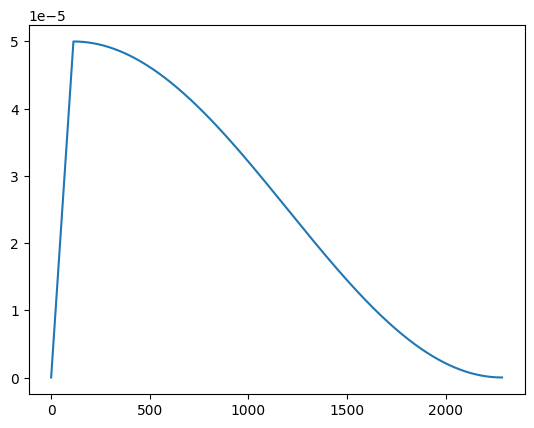

In [5]:
from cosine_lr_scheduler import CosineLRScheduler
import matplotlib.pyplot as plt

PEAK_LR = 5e-5
END_LR = 1e-8
INIT_LR = 1e-8
WARMUP_RATE = 0.05
EPOCHS = 3
TOTAL_STEPS = len(train) * EPOCHS

lr_scheduler = CosineLRScheduler(TOTAL_STEPS,peak_lr=PEAK_LR,min_lr=END_LR,
                                 init_lr=INIT_LR,warmup_rate=WARMUP_RATE)

plt.plot([lr_scheduler(i) for i in range(1,TOTAL_STEPS+1)])

In [6]:
class GeometricPooling(nn.Module):
    
    def __init__(self,temp=1):
        super().__init__()
        self.score = None
        self.temp = temp
    
    def forward(self,x,mask):
        mean_vec = (x * mask[:,:,torch.newaxis]).sum(1)
        mean_vec = mean_vec / torch.norm(mean_vec,dim=-1)[:,torch.newaxis]
        mean_vec = mean_vec[:,torch.newaxis,:]
        mean_vec = mean_vec.transpose(1,2)
        score = torch.matmul(x,mean_vec).squeeze(-1)
        score = torch.where(mask == 0,-1e8,score)
        score = torch.softmax(score,dim=-1).unsqueeze(-1)
        return torch.sum(x * score,dim=1)
    
    
class AttentionPool(nn.Module):
    
    def __init__(self,dim=256,temp=1):
        super().__init__()
        self.dim = dim 
        self.score = None
        self.w = nn.Linear(dim,1,bias=False)
        self.temp = temp
        
    def forward(self,x,mask=None):
        attn = self.w(x)
        if mask is not None:
            mask = mask[:,:,torch.newaxis]
            attn = torch.where(mask == 0,-1e8,attn)
        attn = torch.softmax(attn/self.temp,axis=1)
        self.score = attn
        x = x * attn
        return x.sum(1)
    
    
class MaskedAvgPool(nn.Module):
    
    def __init__(self):
        super().__init__()
        
    def forward(self,x,mask=None):
        if mask is not None:
            mask = mask[:,:,torch.newaxis]
            attn = torch.where(mask != 0,1,-1e8)
            attn = torch.softmax(attn,axis=1)
            x = x * attn
            return x.sum(1)
        else:
            return x.sum(1)/len(x)

In [7]:
from torchinfo import summary


class Classifier(nn.Module):
    
    def __init__(self,dim=256,n_classes=1,pool_typ='avg_pool'):
        super().__init__()
        self.electra = AutoModel.from_pretrained("google/electra-small-discriminator")
        self.cls_head = nn.Linear(dim,n_classes)
        self.pool_type = pool_typ
        self.pooling = nn.ModuleDict({"avg_pool":MaskedAvgPool(),
                                      "attn_pool":AttentionPool(dim),
                                      "geometric_pool":GeometricPooling()})
        
    def forward(self,x,return_pool=False):
        ids,mask = x
        x = self.electra(input_ids=ids,attention_mask=mask)
        x = x['last_hidden_state']
        x = self.pooling[self.pool_type](x,mask=mask)
        if return_pool:
            return x
        x = self.cls_head(x)
        return x
    

reset_random_seeds()


model = Classifier(n_classes=1)
print(summary(model))
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

Layer (type:depth-idx)                                       Param #
Classifier                                                   --
├─ElectraModel: 1-1                                          --
│    └─ElectraEmbeddings: 2-1                                --
│    │    └─Embedding: 3-1                                   3,906,816
│    │    └─Embedding: 3-2                                   65,536
│    │    └─Embedding: 3-3                                   256
│    │    └─LayerNorm: 3-4                                   256
│    │    └─Dropout: 3-5                                     --
│    └─Linear: 2-2                                           33,024
│    └─ElectraEncoder: 2-3                                   --
│    │    └─ModuleList: 3-6                                  9,477,120
├─Linear: 1-2                                                257
├─ModuleDict: 1-3                                            --
│    └─MaskedAvgPool: 2-4                                    --
│    └─Att

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics_dict(y_true, y_pred):
    """
    Returns a dictionary of core classification metrics.
    Automatically handles binary (0/1) vs multiclass averaging.
    """
    # Auto-detect strategy: use 'binary' if labels are just 0 and 1, otherwise use 'weighted'
    is_standard_binary = len(set(y_true)) <= 2 and set(y_true).issubset({0, 1})
    avg = 'binary' if is_standard_binary else 'weighted'
    
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average=avg, zero_division=0),
        "recall": recall_score(y_true, y_pred, average=avg, zero_division=0),
        "f1": f1_score(y_true, y_pred, average=avg, zero_division=0)
    }

metrics = {"avg_pool":None,"attn_pool":None,'geometric_pool':None}



In [9]:
from tqdm.auto import tqdm


def train_model(data,model,EPOCHS,file='saved_weights.pt'):

    global losses
    
    opt = torch.optim.AdamW(model.parameters(),weight_decay=0.01)
    loss_fn = nn.BCEWithLogitsLoss()

    train,test = data

    losses = {'train':[],'valid':[]}
    
    step = 1

    for e in range(1,EPOCHS + 1):

        print(f"{e}/{EPOCHS}")
        print(f"Learning Rate = {lr_scheduler(step)}")

        loss = 0
        model.train()

        for i,batch in enumerate(tqdm(train),1):

            lr = lr_scheduler(step)
            opt.param_groups[0]['lr'] = lr

            opt.zero_grad()

            ids,mask,y = batch
            ids = ids.to(device)
            mask = mask.to(device)
            y = y.to(device)
            y = y.float().unsqueeze(1) 
            pred = model([ids,mask])
            batch_loss = loss_fn(pred,y)
            batch_loss.backward()
            opt.step()

            loss += batch_loss.item()
            
            step += 1

        loss = round(loss / len(train),4)
        losses['train'].append(loss)
        train_loss = loss

        model.eval()
        loss = 0

        with torch.no_grad():

            for i,batch in enumerate(tqdm(test)):

                ids,mask,y = batch
                ids = ids.to(device)
                mask = mask.to(device)
                y = y.to(device)
                y = y.float().unsqueeze(1) 
                pred = model([ids,mask])
                batch_loss = loss_fn(pred,y)
                loss += batch_loss.item()
        
        print(f'Train Loss = {train_loss}')
        loss = round(loss / len(test),4)
        print(f"Val Loss = {loss}")


        if e == 1 or loss < min(losses['valid']):
            torch.save(model.state_dict(),file)
            print("--weights saved")

        losses['valid'].append(loss)
        print('--------------------------------------')
        print()

In [10]:
reset_random_seeds()

model = Classifier(n_classes=1,pool_typ='avg_pool')
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

train_model((train,test),model,EPOCHS=EPOCHS,file='avg_pool.pt')

1/3
Learning Rate = 1e-08


  0%|          | 0/762 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

Train Loss = 0.4869
Val Loss = 0.4051
--weights saved
--------------------------------------

2/3
Learning Rate = 3.97726339297143e-05


  0%|          | 0/762 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

Train Loss = 0.3497
Val Loss = 0.4122
--------------------------------------

3/3
Learning Rate = 1.3683285029003591e-05


  0%|          | 0/762 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

Train Loss = 0.266
Val Loss = 0.4368
--------------------------------------



In [11]:
state_dict = torch.load('avg_pool.pt', map_location=device)
model.load_state_dict(state_dict)

<All keys matched successfully>

              precision    recall  f1-score   support

           0       0.82      0.90      0.86       882
           1       0.85      0.72      0.78       641

    accuracy                           0.83      1523
   macro avg       0.83      0.81      0.82      1523
weighted avg       0.83      0.83      0.83      1523

0.7804878048780488


<Axes: >

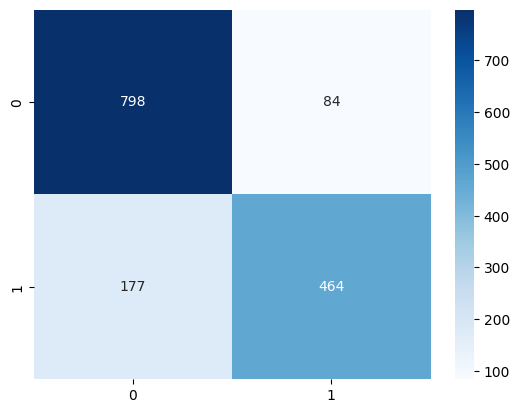

In [12]:
from sklearn.metrics import classification_report,f1_score,confusion_matrix
import seaborn as sb

preds = []

with torch.no_grad():

#     for x,mask, _ in test:
#         x = x.to(device)
#         mask = mask.to(device)
#         pred = model([x,mask])
#         pred = torch.softmax(pred,-1)
#         pred = torch.argmax(pred,1).cpu().numpy()
#         preds.extend(pred)

    for x,mask, _ in test:
        x = x.to(device)
        mask = mask.to(device)
        pred = model([x,mask])
        pred = torch.sigmoid(pred) 
        pred = (pred.squeeze(-1) >= 0.5).int().cpu().numpy()
        if pred.ndim == 0:
            preds.append(pred.item())
        else:
            preds.extend(pred)

print(classification_report(ytest,preds))
# print(f1_score(ytest,preds,average='macro'))  
print(f1_score(ytest,preds))  

sb.heatmap(confusion_matrix(ytest,preds),cmap='Blues',annot=True,fmt='d') 

In [13]:
metrics['avg_pool'] = get_metrics_dict(ytest,preds)

In [14]:
reset_random_seeds()

model = Classifier(n_classes=1,pool_typ='attn_pool')
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

train_model((train,test),model,EPOCHS=EPOCHS,file='attn_pool.pt')

1/3
Learning Rate = 1e-08


  0%|          | 0/762 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

Train Loss = 0.4876
Val Loss = 0.4135
--weights saved
--------------------------------------

2/3
Learning Rate = 3.97726339297143e-05


  0%|          | 0/762 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

Train Loss = 0.349
Val Loss = 0.4289
--------------------------------------

3/3
Learning Rate = 1.3683285029003591e-05


  0%|          | 0/762 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

Train Loss = 0.266
Val Loss = 0.4486
--------------------------------------



In [15]:
state_dict = torch.load('attn_pool.pt', map_location=device)
model.load_state_dict(state_dict)

<All keys matched successfully>

              precision    recall  f1-score   support

           0       0.81      0.92      0.86       882
           1       0.86      0.71      0.78       641

    accuracy                           0.83      1523
   macro avg       0.84      0.81      0.82      1523
weighted avg       0.83      0.83      0.83      1523

0.7777777777777778


<Axes: >

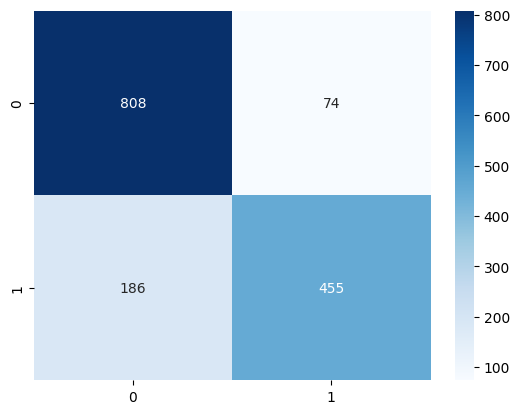

In [16]:
from sklearn.metrics import classification_report,f1_score,confusion_matrix
import seaborn as sb

preds = []

with torch.no_grad():

#     for x,mask, _ in test:
#         x = x.to(device)
#         mask = mask.to(device)
#         pred = model([x,mask])
#         pred = torch.softmax(pred,-1)
#         pred = torch.argmax(pred,1).cpu().numpy()
#         preds.extend(pred)

    for x,mask, _ in test:
        x = x.to(device)
        mask = mask.to(device)
        pred = model([x,mask])
        pred = torch.sigmoid(pred) 
        pred = (pred.squeeze(-1) >= 0.5).int().cpu().numpy()
        if pred.ndim == 0:
            preds.append(pred.item())
        else:
            preds.extend(pred)

print(classification_report(ytest,preds))
# print(f1_score(ytest,preds,average='macro'))  
print(f1_score(ytest,preds))  

sb.heatmap(confusion_matrix(ytest,preds),cmap='Blues',annot=True,fmt='d') 

In [17]:
metrics['attn_pool'] = get_metrics_dict(ytest,preds)

In [18]:
reset_random_seeds()

model = Classifier(n_classes=1,pool_typ='geometric_pool')
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

train_model((train,test),model,EPOCHS=EPOCHS,file='geometric_pool.pt')

1/3
Learning Rate = 1e-08


  0%|          | 0/762 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

Train Loss = 0.4904
Val Loss = 0.4027
--weights saved
--------------------------------------

2/3
Learning Rate = 3.97726339297143e-05


  0%|          | 0/762 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

Train Loss = 0.3498
Val Loss = 0.4206
--------------------------------------

3/3
Learning Rate = 1.3683285029003591e-05


  0%|          | 0/762 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

Train Loss = 0.2685
Val Loss = 0.4392
--------------------------------------



In [19]:
state_dict = torch.load('geometric_pool.pt', map_location=device)
model.load_state_dict(state_dict)

<All keys matched successfully>

              precision    recall  f1-score   support

           0       0.82      0.91      0.86       882
           1       0.86      0.72      0.78       641

    accuracy                           0.83      1523
   macro avg       0.84      0.82      0.82      1523
weighted avg       0.83      0.83      0.83      1523

0.782312925170068


<Axes: >

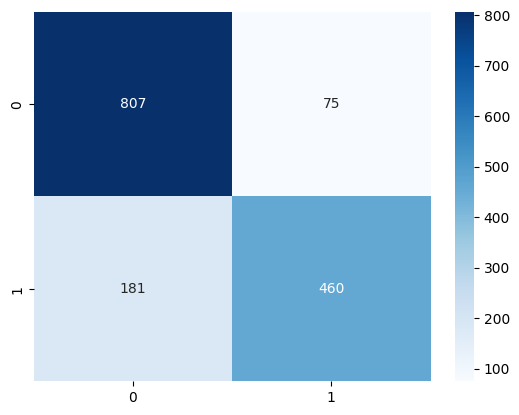

In [20]:
from sklearn.metrics import classification_report,f1_score,confusion_matrix
import seaborn as sb

preds = []

with torch.no_grad():

#     for x,mask, _ in test:
#         x = x.to(device)
#         mask = mask.to(device)
#         pred = model([x,mask])
#         pred = torch.softmax(pred,-1)
#         pred = torch.argmax(pred,1).cpu().numpy()
#         preds.extend(pred)

    for x,mask, _ in test:
        x = x.to(device)
        mask = mask.to(device)
        pred = model([x,mask])
        pred = torch.sigmoid(pred) 
        pred = (pred.squeeze(-1) >= 0.5).int().cpu().numpy()
        if pred.ndim == 0:
            preds.append(pred.item())
        else:
            preds.extend(pred)

print(classification_report(ytest,preds))
# print(f1_score(ytest,preds,average='macro'))  
print(f1_score(ytest,preds))  

sb.heatmap(confusion_matrix(ytest,preds),cmap='Blues',annot=True,fmt='d') 

In [21]:
metrics['geometric_pool'] = get_metrics_dict(ytest,preds)

In [22]:
metrics

{'avg_pool': {'accuracy': 0.8286277084701248,
  'precision': 0.8467153284671532,
  'recall': 0.7238689547581904,
  'f1': 0.7804878048780488},
 'attn_pool': {'accuracy': 0.8292843072882469,
  'precision': 0.8601134215500945,
  'recall': 0.7098283931357254,
  'f1': 0.7777777777777778},
 'geometric_pool': {'accuracy': 0.8319107025607354,
  'precision': 0.8598130841121495,
  'recall': 0.717628705148206,
  'f1': 0.782312925170068}}

In [23]:
import json


with open("disaster_tweet_metrics.json",'w') as f:
    json.dump(metrics,f)

In [24]:
def load_model(pool_type):
    model = Classifier(n_classes=1,pool_typ=pool_type)
    model = model.to('cuda')
    state_dict = torch.load(f'{pool_type}.pt', map_location='cuda')
    model.load_state_dict(state_dict)
    return model

In [25]:
model0 = load_model('avg_pool')
model1 = load_model('attn_pool')
model2 = load_model('geometric_pool')

In [26]:
def get_pooled_vectors(model,test):
    
    model.eval()
    
    with torch.no_grad():

        vectors = []

        for x,mask, _ in test:
            x = x.to('cuda')
            mask = mask.to('cuda')
            pool_vec = model([x,mask],return_pool=True)
            pool_vec = pool_vec.cpu().numpy()
            vectors.extend(pool_vec)
        
        vectors = np.array(vectors,dtype=np.float32)
        
        return vectors

In [27]:
vectors0 = get_pooled_vectors(model0,test)
vectors1 = get_pooled_vectors(model1,test)
vectors2 = get_pooled_vectors(model2,test)

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

def cluster_eval(embeddings,true_labels,name='',classes=2):
    kmeans = KMeans(n_clusters=classes, n_init=10, random_state=42)
    cluster_preds = kmeans.fit_predict(embeddings)
    ari = adjusted_rand_score(true_labels, cluster_preds)
    print(f"Clustering ARI against True Sentiment: {ari:.4f} ({name})")
    return ari,name

In [29]:
cluster_eval_metrics = {}

In [32]:
reset_random_seeds()

ari,name = cluster_eval(vectors0,ytest,'avg_pool')
cluster_eval_metrics[name] = ari

ari,name = cluster_eval(vectors1,ytest,'attn_pool')
cluster_eval_metrics[name] = ari

ari,name = cluster_eval(vectors2,ytest,'geometric_pool')
cluster_eval_metrics[name] = ari

Clustering ARI against True Sentiment: 0.4164 (avg_pool)
Clustering ARI against True Sentiment: 0.4407 (attn_pool)
Clustering ARI against True Sentiment: 0.4158 (geometric_pool)


In [33]:
with open("disaster_tweet_cluster_metrics.json",'w') as f:
    json.dump(cluster_eval_metrics,f)